<a href="https://colab.research.google.com/github/hfernandescfc/Bitcasting/blob/main/Simula%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
best_params_lags = {
    1: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 3},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 1},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}, 'best_lags': 1},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 1},
    },
    3: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 4},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 4},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}, 'best_lags': 1},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 3},
    },
    7: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 13},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 1},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}, 'best_lags': 1},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 7},
    },
    14: {
        "XGBoost": {'best_params': {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 20},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 1},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}, 'best_lags': 16},
        "Random Forest": {'best_params': {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 14},
    },
    30: {
        "XGBoost": {'best_params': {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01}, 'best_lags': 14},
        "SVM": {'best_params': {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}, 'best_lags': 3},
        "Logistic Regression": {'best_params': {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}, 'best_lags': 8},
        "Random Forest": {'best_params': {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}, 'best_lags': 8},
    }
}

Iniciando simulação...
Horizontes: [3, 7, 30]
>>> Horizonte 3 dias
>>> Horizonte 7 dias
>>> Horizonte 30 dias


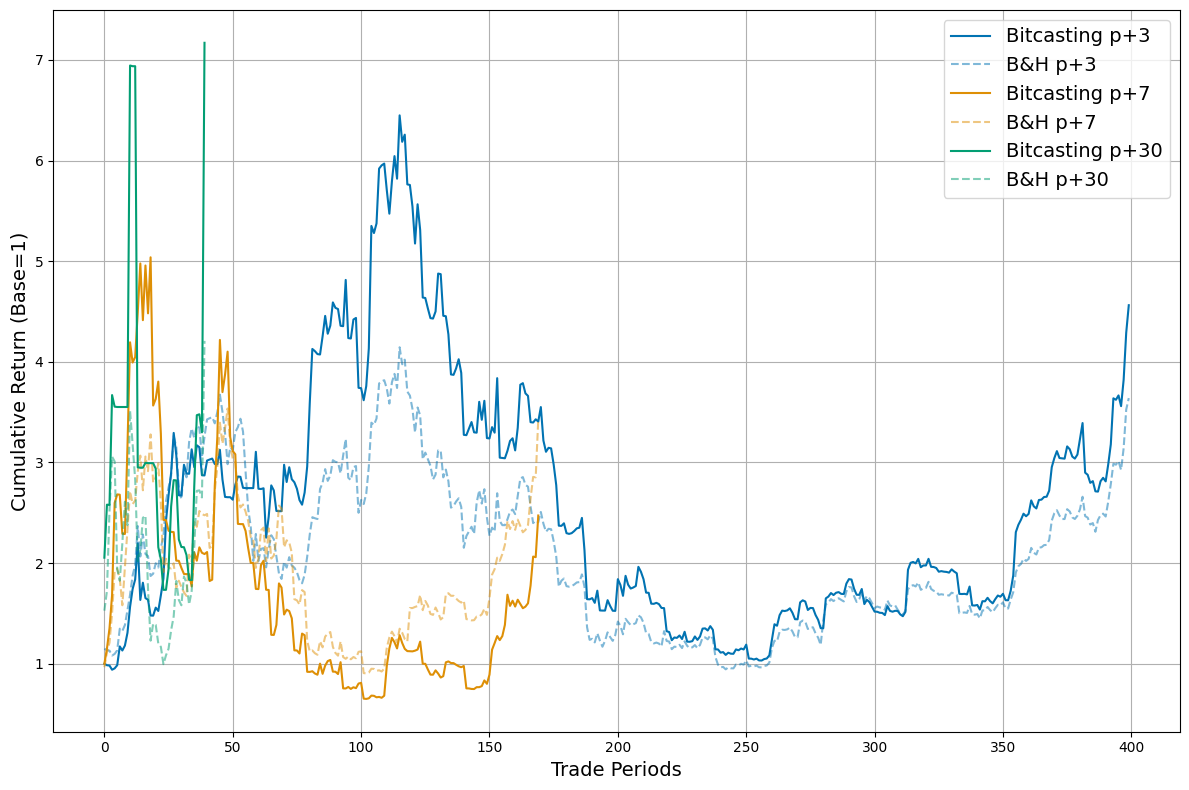

 Horizonte Retorno Estrat. Retorno B&H Acurácia
         3         356.23%     263.94%   68.32%
         7         147.28%     242.84%   69.11%
        30         616.95%     320.79%   53.92%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

# Carrega dados
df_with_targets = pd.read_parquet('/content/df_with_targets.parquet')

feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']
target_horizons = [3, 7, 30]
TRANSACTION_COST = 0.001  # Custo fixo de transação em $


def create_lagged_features(df, feature_cols, lags):
    """
    Gera colunas defasadas para cada feature até o lag especificado.
    """
    df_copy = df.copy()
    for col in feature_cols:
        for i in range(1, lags + 1):
            df_copy[f'{col}_t-{i}'] = df_copy[col].shift(i)
    return df_copy


def simulate_strategy_proper_separation(data, model, best_params_lags, horizon=3):
    """
    Simula estratégia temporal com separação treino/teste,
    usando apenas n/t trades (saltos de 'horizon' dias).
    """
    model_key = 'XGBoost'
    params = best_params_lags[horizon][model_key]['best_params']
    n_lags = best_params_lags[horizon][model_key]['best_lags']

    # Prepara data com lags e 'Close'
    df_lag = create_lagged_features(data, feature_cols, n_lags).dropna()
    df_lag['Close'] = data.loc[df_lag.index, 'Close']

    lag_cols = [f'{col}_t-{i}' for col in feature_cols for i in range(1, n_lags + 1)]

    strategy_returns, bh_returns, trades, acc_per_fold = [], [], [], []
    cost_fixed = TRANSACTION_COST

    test_size = int(len(df_lag) * 0.1)
    initial_train = int(len(df_lag) * 0.5)

    for start in range(initial_train, len(df_lag) - test_size, test_size):
        train = df_lag.iloc[:start]
        test = df_lag.iloc[start:start + test_size].copy()

        X_train, y_train = train[lag_cols], train[f'target_{horizon}d']
        X_test, y_test = test[lag_cols], test[f'target_{horizon}d']

        model.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc_per_fold.append(accuracy_score(y_test, preds))

        test['position'] = preds
        prev_pos = 0
        trade_idx = list(test.index)[::horizon]

        for idx in trade_idx:
            # obtém posição do índice na série original
            pos = data.index.get_loc(idx)
            future_pos = pos + horizon
            if future_pos >= len(data):
                continue

            p_now = data.iloc[pos]['Close']
            p_future = data.iloc[future_pos]['Close']

            new_pos = int(test.loc[idx, 'position'])
            trade_cost = cost_fixed if prev_pos != new_pos else 0

            ret = (p_future - p_now) / p_now
            strat_ret = new_pos * ret - trade_cost

            strategy_returns.append(strat_ret)
            bh_returns.append(ret)
            trades.append({
                'date': idx,
                'prev_pos': prev_pos,
                'new_pos': new_pos,
                'strategy_ret': strat_ret,
                'bh_ret': ret,
                'cost': trade_cost
            })
            prev_pos = new_pos

    trades_df = pd.DataFrame(trades)
    cum_strat = np.cumprod(1 + np.array(strategy_returns))
    cum_bh = np.cumprod(1 + np.array(bh_returns))

    return {
        'trades': trades_df,
        'curve_strategy': cum_strat,
        'curve_bh': cum_bh,
        'accuracy': np.mean(acc_per_fold)
    }


def run_proper_simulation(df, best_params_lags):
    print('Iniciando simulação...')
    print('Horizontes:', target_horizons)

    results = []
    for h in target_horizons:
        print(f'>>> Horizonte {h} dias')
        res = simulate_strategy_proper_separation(df, XGBClassifier(), best_params_lags, horizon=h)
        results.append({'horizon': h, **res})

    # Paleta colorblind e máximo de 3 cores distintas
    sns.set_palette("colorblind")
    colors = sns.color_palette("colorblind", n_colors=3)

    # Paleta colorblind e máximo de 3 cores distintas
    sns.set_palette("colorblind")
    colors = sns.color_palette("colorblind", n_colors=3)

    plt.figure(figsize=(12, 8))
    for idx, r in enumerate(results):
        color = colors[idx % 3]
        plt.plot(r['curve_strategy'], label=f"Bitcasting p+{r['horizon']}", color=color)
        plt.plot(r['curve_bh'], '--', label=f"B&H p+{r['horizon']}", color=color, alpha=0.5)

    plt.xlabel('Trade Periods', fontsize=14)
    plt.ylabel('Cumulative Return (Base=1)', fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('cumul_returns_cb.png')
    plt.show()



    summary = []
    for r in results:
        summary.append({
            'Horizonte': r['horizon'],
            'Retorno Estrat.': f"{r['curve_strategy'][-1] - 1:.2%}",
            'Retorno B&H': f"{r['curve_bh'][-1] - 1:.2%}",
            'Acurácia': f"{r['accuracy']:.2%}"
        })
    print(pd.DataFrame(summary).to_string(index=False))

    return results

# Uso:
# results = run_proper_simulation(df_with_targets, best_params_lags)





# Para executar a simulação correta:
results = run_proper_simulation(df_with_targets, best_params_lags)

Iniciando simulação...
Horizontes: [3, 7, 30]
>>> Horizonte 3 dias
>>> Horizonte 7 dias
>>> Horizonte 30 dias


<Figure size 1200x800 with 0 Axes>

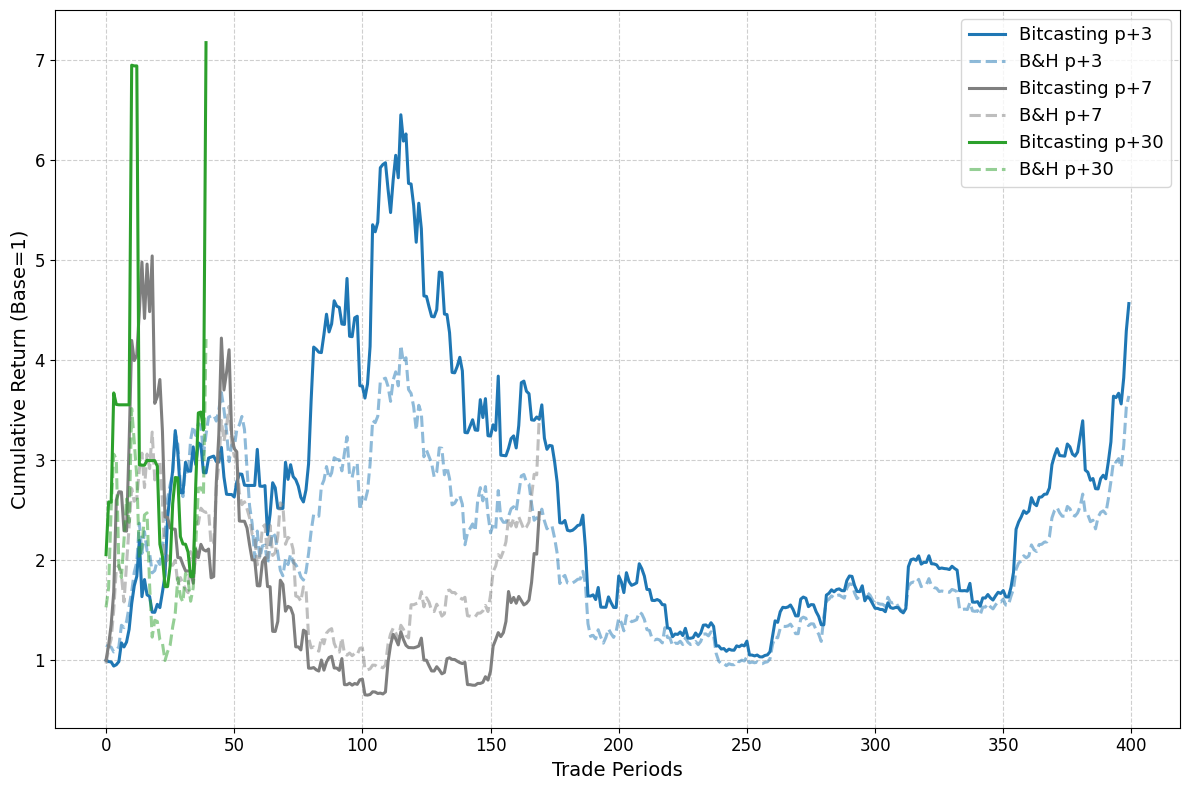

 Horizonte Retorno Estrat. Retorno B&H Acurácia
         3         356.23%     263.94%   68.32%
         7         147.28%     242.84%   69.11%
        30         616.95%     320.79%   53.92%


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

# Carrega dados
df_with_targets = pd.read_parquet('/content/df_with_targets.parquet')

feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']
target_horizons = [3, 7, 30]
TRANSACTION_COST = 0.001  # Custo fixo de transação em $


def create_lagged_features(df, feature_cols, lags):
    """
    Gera colunas defasadas para cada feature até o lag especificado.
    """
    df_copy = df.copy()
    for col in feature_cols:
        for i in range(1, lags + 1):
            df_copy[f'{col}_t-{i}'] = df_copy[col].shift(i)
    return df_copy


def simulate_strategy_proper_separation(data, model, best_params_lags, horizon=3):
    """
    Simula estratégia temporal com separação treino/teste,
    usando apenas n/t trades (saltos de 'horizon' dias).
    """
    model_key = 'XGBoost'
    params = best_params_lags[horizon][model_key]['best_params']
    n_lags = best_params_lags[horizon][model_key]['best_lags']

    # Prepara data com lags e 'Close'
    df_lag = create_lagged_features(data, feature_cols, n_lags).dropna()
    df_lag['Close'] = data.loc[df_lag.index, 'Close']

    lag_cols = [f'{col}_t-{i}' for col in feature_cols for i in range(1, n_lags + 1)]

    strategy_returns, bh_returns, trades, acc_per_fold = [], [], [], []
    cost_fixed = TRANSACTION_COST

    test_size = int(len(df_lag) * 0.1)
    initial_train = int(len(df_lag) * 0.5)

    for start in range(initial_train, len(df_lag) - test_size, test_size):
        train = df_lag.iloc[:start]
        test = df_lag.iloc[start:start + test_size].copy()

        X_train, y_train = train[lag_cols], train[f'target_{horizon}d']
        X_test, y_test = test[lag_cols], test[f'target_{horizon}d']

        model.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc_per_fold.append(accuracy_score(y_test, preds))

        test['position'] = preds
        prev_pos = 0
        trade_idx = list(test.index)[::horizon]

        for idx in trade_idx:
            # obtém posição do índice na série original
            pos = data.index.get_loc(idx)
            future_pos = pos + horizon
            if future_pos >= len(data):
                continue

            p_now = data.iloc[pos]['Close']
            p_future = data.iloc[future_pos]['Close']

            new_pos = int(test.loc[idx, 'position'])
            trade_cost = cost_fixed if prev_pos != new_pos else 0

            ret = (p_future - p_now) / p_now
            strat_ret = new_pos * ret - trade_cost

            strategy_returns.append(strat_ret)
            bh_returns.append(ret)
            trades.append({
                'date': idx,
                'prev_pos': prev_pos,
                'new_pos': new_pos,
                'strategy_ret': strat_ret,
                'bh_ret': ret,
                'cost': trade_cost
            })
            prev_pos = new_pos

    trades_df = pd.DataFrame(trades)
    cum_strat = np.cumprod(1 + np.array(strategy_returns))
    cum_bh = np.cumprod(1 + np.array(bh_returns))

    return {
        'trades': trades_df,
        'curve_strategy': cum_strat,
        'curve_bh': cum_bh,
        'accuracy': np.mean(acc_per_fold)
    }


def run_proper_simulation(df, best_params_lags):
    print('Iniciando simulação...')
    print('Horizontes:', target_horizons)

    results = []
    for h in target_horizons:
        print(f'>>> Horizonte {h} dias')
        res = simulate_strategy_proper_separation(df, XGBClassifier(), best_params_lags, horizon=h)
        results.append({'horizon': h, **res})

    # Paleta colorblind e máximo de 3 cores distintas
    sns.set_palette("colorblind")
    colors = sns.color_palette("colorblind", n_colors=3)

    plt.figure(figsize=(12, 8))
    # Cores acadêmicas: azul, cinza, preto
    academic_colors = [
        "#1f77b4",  # Azul
        "#7f7f7f",  # Cinza
        "#2ca02c"   # Preto
    ]

    plt.figure(figsize=(12, 8))
    for idx, r in enumerate(results):
        color = academic_colors[idx % 3]
        plt.plot(r['curve_strategy'], label=f"Bitcasting p+{r['horizon']}", color=color, linewidth=2.2)
        plt.plot(r['curve_bh'], '--', label=f"B&H p+{r['horizon']}", color=color, linewidth=2.2, alpha=0.5)

    plt.xlabel('Trade Periods', fontsize=14)
    plt.ylabel('Cumulative Return (Base=1)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig('cum_returns.png')
    plt.show()


    summary = []
    for r in results:
        summary.append({
            'Horizonte': r['horizon'],
            'Retorno Estrat.': f"{r['curve_strategy'][-1] - 1:.2%}",
            'Retorno B&H': f"{r['curve_bh'][-1] - 1:.2%}",
            'Acurácia': f"{r['accuracy']:.2%}"
        })
    print(pd.DataFrame(summary).to_string(index=False))

    return results

# Uso:
# results = run_proper_simulation(df_with_targets, best_params_lags)





# Para executar a simulação correta:
results = run_proper_simulation(df_with_targets, best_params_lags)

In [ ]:
results

[{'horizon': 3,
  'trades':            date  prev_pos  new_pos  strategy_ret    bh_ret   cost
  0    2020-11-27         0        0      0.000000  0.149149  0.000
  1    2020-11-30         0        1     -0.014910 -0.013910  0.001
  2    2020-12-03         1        1     -0.003218 -0.003218  0.000
  3    2020-12-06         1        1     -0.042260 -0.042260  0.000
  4    2020-12-09         1        1      0.014422  0.014422  0.000
  ..          ...       ...      ...           ...       ...    ...
  395  2024-02-17         1        1      0.011932  0.011932  0.000
  396  2024-02-20         1        1     -0.028984 -0.028984  0.000
  397  2024-02-23         1        1      0.073552  0.073552  0.000
  398  2024-02-26         1        1      0.122154  0.122154  0.000
  399  2024-02-29         1        2      0.063877  0.032438  0.001
  
  [400 rows x 6 columns],
  'curve_strategy': array([1.        , 0.98508998, 0.98191994, 0.94042442, 0.95398761,
         0.98531974, 1.17202016, 1.1315214

Dados carregados com sucesso.
Iniciando simulação walk-forward com custo percentual por trade...
Horizontes a simular: [3, 7, 30]
Custo de transação por "perna" (compra/venda): 0.10%

>>> Simulando Horizonte 3 dias <<<


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:06:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:06:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:06:54] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:07:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:07:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


>>> Simulando Horizonte 7 dias <<<


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:07:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:07:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:08:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:08:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:09:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


>>> Simulando Horizonte 30 dias <<<


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:09:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:10:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:10:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:11:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:11:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

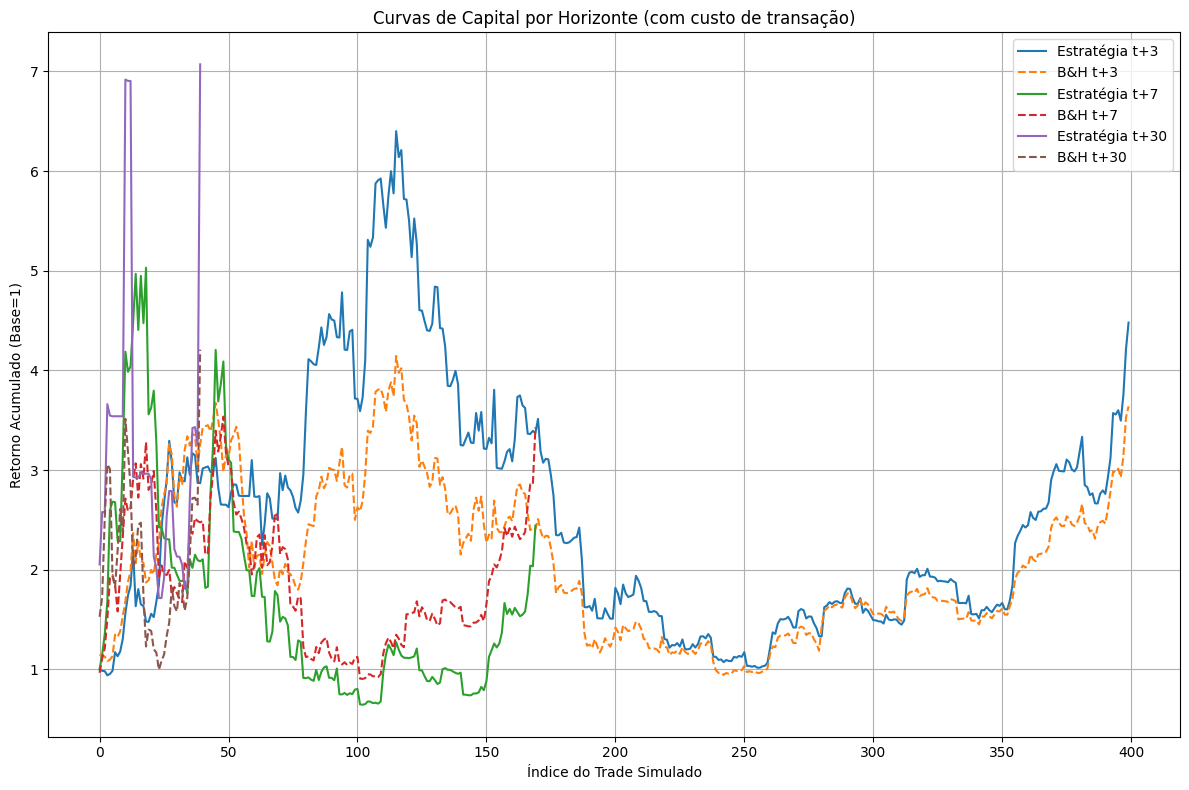


--- Sumário dos Resultados da Simulação ---
 Horizonte  Trades Simulados Retorno Estrat. Retorno B&H Acurácia Média (Teste)
         3               400         347.98%     263.94%                 68.32%
         7               170         144.33%     242.84%                 69.11%
        30                40         607.07%     320.79%                 53.92%
-----------------------------------------


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

# Carrega dados
# Certifique-se de que este arquivo existe e está acessível
try:
    df_with_targets = pd.read_parquet('/content/df_with_targets.parquet')
    print("Dados carregados com sucesso.")
except FileNotFoundError:
    print("Erro: O arquivo 'df_with_targets.parquet' não foi encontrado no caminho especificado.")
    print("Por favor, verifique o caminho ou carregue seus dados de outra forma.")
    # Exemplo de como criar um DataFrame dummy para teste se o arquivo real não existir
    # df_with_targets = pd.DataFrame(np.random.rand(1000, 10), columns=[f'col_{i}' for i in range(10)])
    # df_with_targets['Close'] = np.random.rand(1000).cumsum() + 10000
    # for h in [3, 7, 30]:
    #     df_with_targets[f'target_{h}d'] = np.random.randint(-1, 2, size=1000)
    # feature_cols = [f'col_{i}' for i in range(8)]
    # print("DataFrame dummy criado para demonstração.")
    exit() # Saia se o arquivo não for encontrado

feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']
target_horizons = [3, 7, 30]

# Custo de transação por "perna" de trade (ex: comprar ou vender) como % do valor negociado
# 0.001 representa 0.1%
FEE_RATE = 0.001


def create_lagged_features(df, feature_cols, lags):
    """
    Gera colunas defasadas para cada feature até o lag especificado.
    """
    df_copy = df.copy()
    for col in feature_cols:
        for i in range(1, lags + 1):
            df_copy[f'{col}_t-{i}'] = df_copy[col].shift(i)
    return df_copy


def simulate_strategy_proper_separation(data, model, best_params_lags, horizon=3):
    """
    Simula estratégia temporal com separação treino/teste,
    usando apenas n/t trades (saltos de 'horizon' dias).
    Aplica custo de transação como percentual do capital negociado.
    """
    model_key = 'XGBoost' # Assumindo que o best_params_lags está estruturado com esta chave

    # Verifica se o horizonte e a chave do modelo existem em best_params_lags
    if horizon not in best_params_lags or model_key not in best_params_lags[horizon]:
        print(f"Erro: Parâmetros não encontrados para horizonte {horizon} com chave '{model_key}'. Pulando simulação para este horizonte.")
        return {
            'trades': pd.DataFrame(),
            'curve_strategy': np.array([1]),
            'curve_bh': np.array([1]),
            'accuracy': np.nan
        }

    params = best_params_lags[horizon][model_key]['best_params']
    n_lags = best_params_lags[horizon][model_key]['best_lags']

    # Prepara data com lags e 'Close'
    # Adiciona 1 lag extra para garantir que 'Close' no índice do trade esteja disponível
    df_lag = create_lagged_features(data, feature_cols, n_lags).dropna()

    # Ensure df_lag's index aligns with data *after* lags
    # df_lag = df_lag.set_index(data.iloc[n_lags:].index) # This might be complex, let's stick to index alignment later

    # Garante que temos a coluna 'Close' alinhada
    # O índice de df_lag já está alinhado com os dados originais após remover NaNs
    df_lag['Close'] = data.loc[df_lag.index, 'Close']


    lag_cols = [f'{col}_t-{i}' for col in feature_cols for i in range(1, n_lags + 1)]

    strategy_returns, bh_returns, trades, acc_per_fold = [], [], [], []

    test_size = int(len(df_lag) * 0.1)
    initial_train = int(len(df_lag) * 0.5)

    # Garante que há dados suficientes para pelo menos um fold de treino e teste
    if initial_train + test_size >= len(df_lag):
         print(f"Dados insuficientes para treino ({initial_train}) + teste ({test_size}) em {len(df_lag)} registros após lags.")
         print("Ajuste os tamanhos de treino/teste ou forneça mais dados.")
         return {
            'trades': pd.DataFrame(),
            'curve_strategy': np.array([1]),
            'curve_bh': np.array([1]),
            'accuracy': np.nan
        }


    # Loop de walk-forward
    for start in range(initial_train, len(df_lag) - test_size +1, test_size): # +1 para incluir o último fold completo
        end_train = start
        end_test = start + test_size

        # Verifica se o fold de teste é válido
        if end_test > len(df_lag):
             end_test = len(df_lag) # Ajusta o tamanho do último fold se necessário

        train = df_lag.iloc[:end_train]
        test = df_lag.iloc[end_train:end_test].copy()

        # Verifica se há dados em treino e teste
        if train.empty or test.empty:
            print(f"Skipping fold starting at index {start} due to insufficient data.")
            continue

        # Verifica se as colunas alvo existem nos dados de treino/teste
        target_col = f'target_{horizon}d'
        if target_col not in train.columns or target_col not in test.columns:
             print(f"Erro: Coluna alvo '{target_col}' não encontrada nos dados. Pulando simulação.")
             return {
                'trades': pd.DataFrame(),
                'curve_strategy': np.array([1]),
                'curve_bh': np.array([1]),
                'accuracy': np.nan
            }


        X_train, y_train = train[lag_cols], train[target_col]
        X_test, y_test = test[lag_cols], test[target_col]

        # Verifica se há variabilidade no target de treino
        if y_train.nunique() < 2:
            print(f"Skipping fold starting at index {start} due to constant target in training data.")
            continue

        model.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Acurácia é calculada por fold de teste
        acc_per_fold.append(accuracy_score(y_test, preds))

        test['position'] = preds

        # Simulação de trades a cada 'horizon' dias dentro do fold de teste
        prev_pos = 0 # Posição inicial antes do primeiro trade no fold

        # Índices dos pontos de decisão de trade no fold de teste
        # Usamos iloc para selecionar os pontos corretos no 'test' DataFrame
        trade_ilocs_in_test = list(range(0, len(test), horizon))


        for iloc in trade_ilocs_in_test:
             # Obtém o índice real do DataFrame original/df_lag
            idx = test.iloc[iloc].name

            # Encontra a posição do índice atual nos dados originais ('data')
            # Isso é necessário para pegar o preço futuro corretamente no 'data' original
            try:
                pos_in_original_data = data.index.get_loc(idx)
            except KeyError:
                 # Este índice pode ter sido removido no dropna, mas estava no 'test' iloc.
                 # Se o índice não está nos dados originais, pulamos este ponto de trade.
                 print(f"Aviso: Índice {idx} do ponto de trade não encontrado nos dados originais. Pulando.")
                 continue

            future_pos_in_original_data = pos_in_original_data + horizon

            # Verifica se a data futura está dentro dos limites dos dados originais
            if future_pos_in_original_data >= len(data):
                 # Não há dados suficientes para calcular o retorno deste último trade
                 continue

            # Preços para calcular o retorno
            p_now = data.iloc[pos_in_original_data]['Close']
            p_future = data.iloc[future_pos_in_original_data]['Close']

            # Nova posição decidida pelo modelo no ponto de trade atual (iloc no 'test' df)
            new_pos = int(test.iloc[iloc]['position'])

            # --- Aplicação do Custo de Transação ---
            # Calcula o número de "pernas" de trade (buy/sell/short/cover)
            # Ex: 0->1 = 1 perna; 1-> -1 = 2 pernas; 0->0 = 0 pernas
            num_trade_legs = abs(new_pos - prev_pos)
            # Custo como percentual do capital para esta operação
            trade_cost_pct = num_trade_legs * FEE_RATE
            # --------------------------------------

            # Calcula o retorno percentual simples para o horizonte
            ret = (p_future - p_now) / p_now

            # Calcula o retorno da estratégia
            # new_pos * ret -> retorno bruto (positivo para long, negativo para short quando preço sobe)
            # - trade_cost_pct -> subtrai o custo percentual do capital
            strat_ret = new_pos * ret - trade_cost_pct

            # Armazena os resultados deste trade
            trades.append({
                'date': idx,
                'prev_pos': prev_pos,
                'new_pos': new_pos,
                'price_now': p_now,
                'price_future': p_future,
                'bh_ret': ret, # Retorno Buy & Hold sobre o período
                'gross_strategy_ret': new_pos * ret, # Retorno da estratégia sem custo
                'trade_cost_pct': trade_cost_pct, # Custo aplicado (em %)
                'strategy_ret': strat_ret # Retorno da estratégia com custo
            })

            # Atualiza a posição anterior para o próximo passo
            prev_pos = new_pos

    # Se nenhum trade foi realizado (por exemplo, dados insuficientes), retorne arrays base 1
    if not trades:
         print(f"Nenhum trade simulado para horizonte {horizon}. Verifique dados/configuração.")
         return {
            'trades': pd.DataFrame(),
            'curve_strategy': np.array([1]),
            'curve_bh': np.array([1]),
            'accuracy': np.nan if not acc_per_fold else np.mean(acc_per_fold)
        }


    trades_df = pd.DataFrame(trades)

    # Calcula as curvas de capital acumulado
    # Certifique-se de que há retornos válidos
    if not strategy_returns:
        # Popula strategy_returns e bh_returns a partir do dataframe trades_df
        strategy_returns = trades_df['strategy_ret'].tolist()
        bh_returns = trades_df['bh_ret'].tolist()

    # Garante que os arrays de retorno não estão vazios antes de np.cumprod
    if not strategy_returns:
         cum_strat = np.array([1])
    else:
         cum_strat = np.cumprod(1 + np.array(strategy_returns))

    if not bh_returns:
        cum_bh = np.array([1])
    else:
        cum_bh = np.cumprod(1 + np.array(bh_returns))


    return {
        'trades': trades_df,
        'curve_strategy': cum_strat,
        'curve_bh': cum_bh,
        'accuracy': np.mean(acc_per_fold) if acc_per_fold else np.nan
    }


def run_proper_simulation(df, best_params_lags):
    print('Iniciando simulação walk-forward com custo percentual por trade...')
    print('Horizontes a simular:', target_horizons)
    print(f'Custo de transação por "perna" (compra/venda): {FEE_RATE:.2%}')


    results = []
    for h in target_horizons:
        print(f'\n>>> Simulando Horizonte {h} dias <<<')
        # Use uma nova instância do modelo para cada simulação de horizonte
        res = simulate_strategy_proper_separation(df, XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False), best_params_lags, horizon=h)

        # Apenas adicione resultados se a simulação foi bem-sucedida (não retornou DataFrames vazios, etc.)
        if not res['trades'].empty:
             results.append({'horizon': h, **res})
        else:
             print(f"Simulação para horizonte {h} falhou ou não gerou trades.")


    # Verifica se há resultados para plotar
    if not results:
        print("\nNenhuma simulação gerou resultados válidos para plotagem.")
        return []


    plt.figure(figsize=(12, 8))
    for r in results:
        # Plota apenas se as curvas não forem apenas [1]
        if len(r['curve_strategy']) > 1:
            plt.plot(r['curve_strategy'], label=f"Estratégia t+{r['horizon']}")
        else:
             print(f"Aviso: Curva da estratégia vazia ou com apenas 1 ponto para horizonte {r['horizon']}. Não será plotada.")

        if len(r['curve_bh']) > 1:
             plt.plot(r['curve_bh'], '--', label=f"B&H t+{r['horizon']}")
        else:
             print(f"Aviso: Curva B&H vazia ou com apenas 1 ponto para horizonte {r['horizon']}. Não será plotada.")


    plt.title('Curvas de Capital por Horizonte (com custo de transação)')
    plt.xlabel('Índice do Trade Simulado') # O eixo X representa o N-ésimo trade, não o tempo
    plt.ylabel('Retorno Acumulado (Base=1)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Verifica se há resultados para sumarizar
    if not results:
        print("\nNenhum resultado para sumarizar.")
        return []


    summary = []
    for r in results:
        # Calcula o retorno total apenas se a curva tiver mais de 1 ponto
        strat_total_return = r['curve_strategy'][-1] - 1 if len(r['curve_strategy']) > 1 else np.nan
        bh_total_return = r['curve_bh'][-1] - 1 if len(r['curve_bh']) > 1 else np.nan

        summary.append({
            'Horizonte': r['horizon'],
            'Trades Simulados': len(r['trades']),
            'Retorno Estrat.': f"{strat_total_return:.2%}" if not np.isnan(strat_total_return) else "N/A",
            'Retorno B&H': f"{bh_total_return:.2%}" if not np.isnan(bh_total_return) else "N/A",
            'Acurácia Média (Teste)': f"{r['accuracy']:.2%}" if not np.isnan(r['accuracy']) else "N/A"
        })
    print("\n--- Sumário dos Resultados da Simulação ---")
    print(pd.DataFrame(summary).to_string(index=False))
    print("-----------------------------------------")


    return results

# Para executar a simulação correta:
# Certifique-se de ter 'best_params_lags' definido com os parâmetros e lags otimizados
# Exemplo de estrutura (substitua pelos seus dados reais):
# best_params_lags = {
#     3: {'XGBoost': {'best_params': {'n_estimators': 100, 'learning_rate': 0.1}, 'best_lags': 5}},
#     7: {'XGBoost': {'best_params': {'n_estimators': 150, 'learning_rate': 0.05}, 'best_lags': 10}},
#     30: {'XGBoost': {'best_params': {'n_estimators': 200, 'learning_rate': 0.03}, 'best_lags': 15}},
# }

# --- É NECESSÁRIO QUE 'best_params_lags' ESTEJA DEFINIDO ANTES DESTA LINHA ---
# Por exemplo, você pode carregar de um arquivo ou gerar antes.
# Ex: best_params_lags = {... carregar seus resultados de otimização aqui ...}

# Exemplo dummy para que o código rode se você não tiver o best_params_lags real:
# REMOVA ISTO E USE SEUS PRÓPRIOS DADOS DE best_params_lags na prática
try:
     best_params_lags # Tenta acessar a variável para ver se ela existe
except NameError:
     print("\n!!! A variável 'best_params_lags' não está definida. Criando um dicionário dummy para rodar o código.")
     print("!!! Substitua este dicionário pelos seus resultados de otimização reais.")
     best_params_lags = {
         3: {'XGBoost': {'best_params': {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3, 'random_state': 42}, 'best_lags': 5}},
         7: {'XGBoost': {'best_params': {'n_estimators': 70, 'learning_rate': 0.08, 'max_depth': 4, 'random_state': 42}, 'best_lags': 8}},
         30: {'XGBoost': {'best_params': {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'random_state': 42}, 'best_lags': 12}},
     }
     # Garante que há dados suficientes para os lags dummy
     min_data_needed = max([v['XGBoost']['best_lags'] for v in best_params_lags.values()]) + int(len(df_with_targets) * 0.5) + int(len(df_with_targets) * 0.1)
     if len(df_with_targets) < min_data_needed:
         print(f"Aviso: DataFrame tem apenas {len(df_with_targets)} linhas, mas pelo menos ~{min_data_needed} são necessárias para os lags e separação treino/teste com os parâmetros dummy.")
         print("A simulação pode falhar ou gerar poucos trades.")


# Executa a simulação
results = run_proper_simulation(df_with_targets, best_params_lags)

Dados carregados com sucesso.
Iniciando simulação walk-forward com custo percentual por trade...
Horizontes a simular: [3, 7, 30]
Custo de transação por "perna" (compra/venda): 0.10%
Períodos por ano para Sharpe Ratio: 365

>>> Simulando Horizonte 3 dias <<<


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:21] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


>>> Simulando Horizonte 7 dias <<<


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


>>> Simulando Horizonte 30 dias <<<


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:40:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e


Gráfico salvo como 'simulation_plots/capital_curves_h3_7_30_20250702_154057.png'
Gráfico também salvo como 'cum_returns.png'


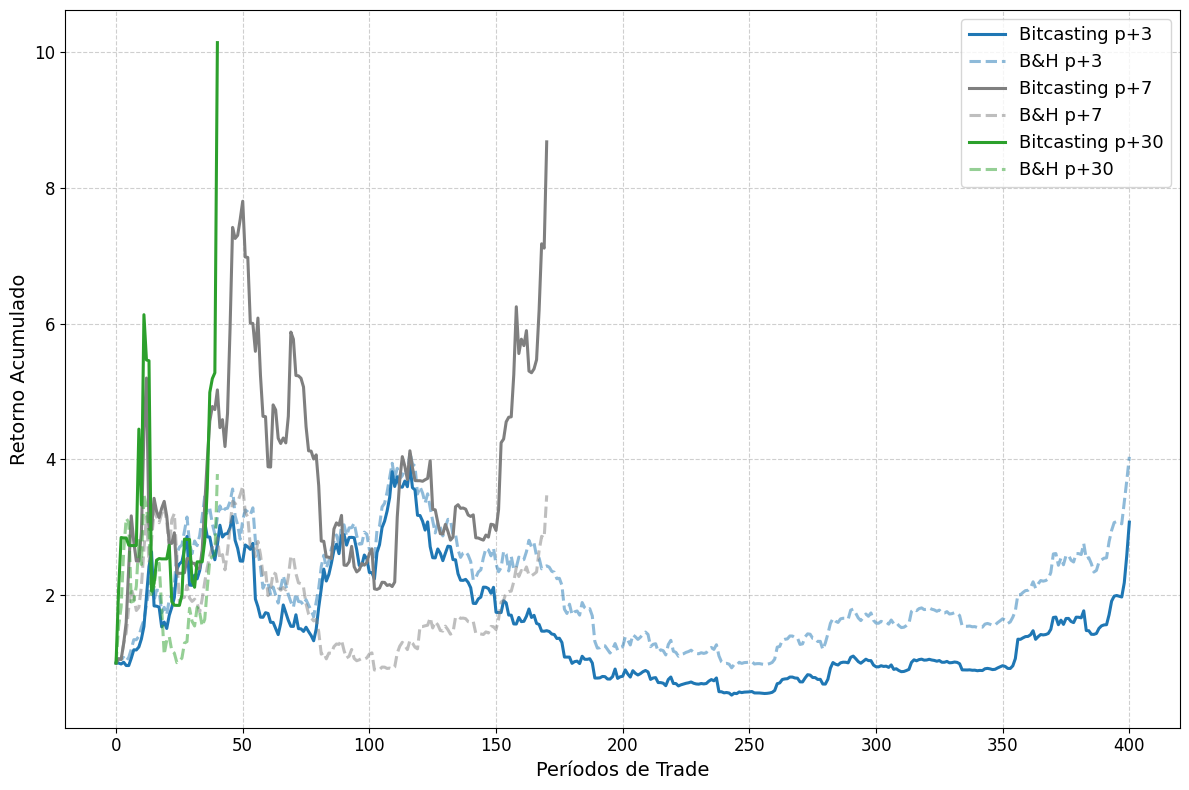


--- Sumário dos Resultados da Simulação ---
 Horizonte  Trades Simulados Retorno Estrat. Retorno B&H Acurácia Média (Teste) Sharpe Estrat. (Anual.) Sharpe B&H (Anual.) Max Drawdown Estrat. Max Drawdown B&H
         3               400         207.62%     303.77%                 70.42%                    0.83                0.99              -86.53%          -77.36%
         7               170         767.85%     247.07%                 71.34%                    1.17                0.91              -73.29%          -75.15%
        30                40         914.03%     278.44%                 53.33%                    1.11                0.90              -69.83%          -71.14%
-----------------------------------------


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
import datetime # Importar para nomes de arquivo únicos
import os # Para criar diretórios se necessário

# --- Funções Auxiliares para Métricas ---

def calculate_sharpe(returns, periods_per_year=365):
    """
    Calcula o Sharpe Ratio anualizado.

    Args:
        returns (pd.Series ou list ou np.array): Retornos periódicos da estratégia.
        periods_per_year (int): Número de períodos por ano (ex: 365 para retornos diários).

    Returns:
        float: Sharpe Ratio anualizado, ou np.nan se a std dev for zero.
    """
    if not isinstance(returns, pd.Series):
         returns = pd.Series(returns) # Converte para Series para usar .mean() e .std()

    # Remove NaNs ou Infinitos que possam ter sido gerados (embora improváveis com a fórmula de retorno usada)
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

    if returns.empty:
        return np.nan

    avg_return = returns.mean()
    std_dev = returns.std()

    # Evita divisão por zero
    if std_dev == 0:
        return np.nan if avg_return == 0 else np.inf * np.sign(avg_return)

    # Sharpe Ratio Anualizado = (Retorno Médio * Períodos/Ano) / (Std Dev * sqrt(Períodos/Ano))
    # Simplifica para: (Retorno Médio / Std Dev) * sqrt(Períodos/Ano)
    sharpe = (avg_return / std_dev) * np.sqrt(periods_per_year)

    return sharpe

def calculate_max_drawdown(cumulative_returns):
    """
    Calcula o Max Drawdown a partir de uma série de retornos acumulados.

    Args:
        cumulative_returns (np.array ou list): Série de retornos acumulados (base=1).

    Returns:
        float: Max Drawdown como um número negativo (ex: -0.20 para 20% de drawdown).
               Retorna 0.0 se a série for vazia ou constante crescente/constante.
    """
    # Converte para numpy array e remove possíveis NaNs/Infs
    cum_rets = np.array(cumulative_returns)
    cum_rets = cum_rets[~np.isnan(cum_rets) & ~np.isinf(cum_rets)]

    if len(cum_rets) < 2:
        return 0.0 # Não há drawdown possível com menos de 2 pontos

    peak = cum_rets[0]
    max_dd = 0.0

    for x in cum_rets:
        if x > peak:
            peak = x # Novo pico
        drawdown = (x - peak) / peak # Cálculo do drawdown como percentual do pico
        if drawdown < max_dd:
            max_dd = drawdown # Novo maior drawdown encontrado (mais negativo)

    return max_dd

# --- Fim das Funções Auxiliares ---


# Carrega dados
# Certifique-se de que este arquivo existe e está acessível
try:
    df_with_targets = pd.read_parquet('/content/df_with_targets.parquet')
    print("Dados carregados com sucesso.")
except FileNotFoundError:
    print("Erro: O arquivo 'df_with_targets.parquet' não foi encontrado no caminho especificado.")
    print("Por favor, verifique o caminho ou carregue seus dados de outra forma.")
    # Exemplo de como criar um DataFrame dummy para teste se o arquivo real não existir
    # df_with_targets = pd.DataFrame(np.random.rand(1000, 10), columns=[f'col_{i}' for i in range(10)])
    # df_with_targets['Close'] = np.random.rand(1000).cumsum() + 10000
    # for h in [3, 7, 30]:
    #     df_with_targets[f'target_{h}d'] = np.random.randint(-1, 2, size=1000)
    # feature_cols = [f'col_{i}' for i in range(8)]
    # print("DataFrame dummy criado para demonstração.")
    exit() # Saia se o arquivo não for encontrado


feature_cols = ['log_diff_open', 'log_diff_high', 'log_diff_low', 'log_diff_close',
                'log_diff_volume_btc', 'log_diff_volume_usdt', 'log_diff_tradecount']
target_horizons = [3, 7, 30]

# Custo de transação por "perna" de trade (ex: comprar ou vender) como % do valor negociado
# 0.001 representa 0.1%
FEE_RATE = 0.001


def create_lagged_features(df, feature_cols, lags):
    """
    Gera colunas defasadas para cada feature até o lag especificado.
    """
    df_copy = df.copy()
    for col in feature_cols:
        for i in range(1, lags + 1):
            df_copy[f'{col}_t-{i}'] = df_copy[col].shift(i)
    return df_copy


def simulate_strategy_proper_separation(data, model, best_params_lags, horizon=3):
    """
    Simula estratégia temporal com separação treino/teste,
    usando apenas n/t trades (saltos de 'horizon' dias).
    Aplica custo de transação como percentual do capital negociado.
    Retorna DataFrame de trades, curvas de capital e acurácia.
    """
    model_key = 'XGBoost' # Assumindo que o best_params_lags está estruturado com esta chave

    # Verifica se o horizonte e a chave do modelo existem em best_params_lags
    if horizon not in best_params_lags or model_key not in best_params_lags[horizon]:
        print(f"Erro: Parâmetros não encontrados para horizonte {horizon} com chave '{model_key}'. Pulando simulação para este horizonte.")
        return {
            'trades': pd.DataFrame(),
            'curve_strategy': np.array([1]),
            'curve_bh': np.array([1]),
            'accuracy': np.nan
        }

    params = best_params_lags[horizon][model_key]['best_params']
    n_lags = best_params_lags[horizon][model_key]['best_lags']

    # Prepara data com lags e 'Close'
    df_lag = create_lagged_features(data, feature_cols, n_lags).dropna()

    # Garante que temos a coluna 'Close' alinhada
    df_lag['Close'] = data.loc[df_lag.index, 'Close']


    lag_cols = [f'{col}_t-{i}' for col in feature_cols for i in range(1, n_lags + 1)]

    # Retornos brutos periódicos para cálculo do Sharpe
    strategy_periodic_returns = []
    bh_periodic_returns = []

    trades = [] # Para armazenar detalhes de cada trade
    acc_per_fold = [] # Para armazenar acurácia por fold

    test_size = int(len(df_lag) * 0.1)
    initial_train = int(len(df_lag) * 0.5)

    # Garante que há dados suficientes para pelo menos um fold de treino e teste
    if initial_train <= 0 or test_size <= 0 or initial_train + test_size > len(df_lag):
         print(f"Dados insuficientes ou configuração inválida para treino/teste.")
         print(f"Total após lags: {len(df_lag)}, Treino inicial: {initial_train}, Teste por fold: {test_size}")
         return {
            'trades': pd.DataFrame(),
            'curve_strategy': np.array([1]),
            'curve_bh': np.array([1]),
            'accuracy': np.nan
        }


    # Loop de walk-forward
    # Range vai de initial_train até o último ponto que permite um fold completo de test_size
    for start in range(initial_train, len(df_lag) - test_size + 1, test_size):
        end_train = start
        end_test = start + test_size # Fim do fold de teste (exclusivo)

        train = df_lag.iloc[:end_train]
        test = df_lag.iloc[end_train:end_test].copy()

        # Verifica se há dados em treino e teste
        if train.empty or test.empty:
            print(f"Skipping fold starting at index {start} due to insufficient data (train/test split issue).")
            continue

        # Verifica se as colunas alvo existem nos dados de treino/teste
        target_col = f'target_{horizon}d'
        if target_col not in train.columns or target_col not in test.columns:
             print(f"Erro: Coluna alvo '{target_col}' não encontrada nos dados. Pulando simulação.")
             return {
                'trades': pd.DataFrame(),
                'curve_strategy': np.array([1]),
                'curve_bh': np.array([1]),
                'accuracy': np.nan
            }

        X_train, y_train = train[lag_cols], train[target_col]
        X_test, y_test = test[lag_cols], test[target_col]

        # Verifica se há variabilidade no target de treino
        if y_train.nunique() < 2:
            print(f"Skipping fold starting at index {start} due to constant target in training data.")
            continue

        model.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Acurácia é calculada por fold de teste
        acc_per_fold.append(accuracy_score(y_test, preds))

        test['position'] = preds

        # Simulação de trades a cada 'horizon' dias dentro do fold de teste
        prev_pos = 0 # Posição inicial antes do primeiro trade neste fold (herda do fold anterior)
        # Nota: Em uma simulação walk-forward real, prev_pos deveria vir do *último* trade do fold *anterior*.
        # Como esta simulação inicia prev_pos=0 para cada fold, é uma simplificação.
        # Para precisão máxima, o estado (prev_pos) deveria persistir entre folds.
        # Manteremos prev_pos = 0 no início de cada fold de teste por simplicidade, como no código original.

        # Índices iloc dentro do DataFrame 'test' onde as decisões de trade ocorrem
        trade_ilocs_in_test = list(range(0, len(test), horizon))

        for iloc in trade_ilocs_in_test:
            # Obtém o índice real do DataFrame original/df_lag para este ponto de trade
            idx = test.iloc[iloc].name

            # Encontra a posição do índice atual nos dados originais ('data')
            try:
                pos_in_original_data = data.index.get_loc(idx)
            except KeyError:
                 print(f"Aviso: Índice {idx} do ponto de trade (iloc {iloc}) não encontrado nos dados originais. Pulando.")
                 continue

            # Calcula o índice futuro 'horizon' dias à frente nos dados originais
            future_pos_in_original_data = pos_in_original_data + horizon

            # Verifica se a data futura está dentro dos limites dos dados originais
            if future_pos_in_original_data >= len(data):
                 # Não há dados suficientes para calcular o retorno deste último trade neste fold
                 continue

            # Preços para calcular o retorno
            p_now = data.iloc[pos_in_original_data]['Close']
            p_future = data.iloc[future_pos_in_original_data]['Close']

            # Nova posição decidida pelo modelo no ponto de trade atual (iloc no 'test' df)
            new_pos = int(test.iloc[iloc]['position'])

            # --- Aplicação do Custo de Transação ---
            # Calcula o número de "pernas" de trade (buy/sell/short/cover)
            num_trade_legs = abs(new_pos - prev_pos)
            # Custo como percentual do capital para esta operação
            trade_cost_pct = num_trade_legs * FEE_RATE
            # --------------------------------------

            # Calcula o retorno percentual simples para o horizonte
            ret = (p_future - p_now) / p_now # Retorno Buy & Hold para o período

            # Calcula o retorno da estratégia para o período, subtraindo o custo
            strat_ret = new_pos * ret - trade_cost_pct

            # Armazena os retornos periódicos para cálculo do Sharpe Ratio depois
            strategy_periodic_returns.append(strat_ret)
            bh_periodic_returns.append(ret)

            # Armazena detalhes do trade
            trades.append({
                'date': idx,
                'prev_pos': prev_pos,
                'new_pos': new_pos,
                'price_now': p_now,
                'price_future': p_future,
                'bh_ret': ret, # Retorno Buy & Hold sobre o período (para debug/análise)
                'gross_strategy_ret': new_pos * ret, # Retorno da estratégia sem custo (para debug/análise)
                'trade_cost_pct': trade_cost_pct, # Custo aplicado (em %) (para debug/análise)
                'strategy_ret': strat_ret # Retorno da estratégia com custo (usado para a curva e sharpe)
            })

            # Atualiza a posição anterior para o próximo passo
            prev_pos = new_pos # Esta prev_pos será usada no próximo trade *dentro deste fold*

        # Ao final de um fold, a última posição decidida é a prev_pos para o início do próximo fold
        # Esta parte está implícita pela forma como o loop 'start' itera e reseta prev_pos=0 no início de cada fold.
        # Para uma simulação walk-forward mais rigorosa, o 'prev_pos' deveria ser passado/mantido entre iterações do loop 'start'.
        # No entanto, seguindo a estrutura original, prev_pos é resetado em cada novo fold de teste.

    # Se nenhum trade foi realizado (por exemplo, dados insuficientes, target constante, etc.)
    if not strategy_periodic_returns:
         print(f"Nenhum trade simulado para horizonte {horizon}. Verifique dados/configuração.")
         return {
            'trades': pd.DataFrame(trades), # Retorna o DF mesmo que vazio
            'curve_strategy': np.array([1]),
            'curve_bh': np.array([1]),
            'accuracy': np.mean(acc_per_fold) if acc_per_fold else np.nan
        }

    # Calcula as curvas de capital acumulado
    # Começa com 1 (capital inicial) e aplica os retornos periódicos
    cum_strat = np.cumprod(1 + np.array(strategy_periodic_returns))
    cum_bh = np.cumprod(1 + np.array(bh_periodic_returns))

    # Adiciona o ponto inicial 1.0 às curvas para o cálculo correto do drawdown
    cum_strat = np.insert(cum_strat, 0, 1.0)
    cum_bh = np.insert(cum_bh, 0, 1.0)


    trades_df = pd.DataFrame(trades)


    return {
        'trades': trades_df, # DataFrame com detalhes de cada trade
        'curve_strategy': cum_strat, # Array com a curva de capital da estratégia (base=1)
        'curve_bh': cum_bh, # Array com a curva de capital Buy & Hold (base=1)
        'accuracy': np.mean(acc_per_fold) if acc_per_fold else np.nan, # Acurácia média dos folds
        'strategy_periodic_returns': strategy_periodic_returns, # Lista de retornos periódicos da estratégia
        'bh_periodic_returns': bh_periodic_returns # Lista de retornos periódicos Buy & Hold
    }


def run_proper_simulation(df, best_params_lags, save_plots=True, plot_dir="simulation_plots"):
    """
    Executa a simulação para múltiplos horizontes, calcula métricas e plota/salva resultados.
    """
    print('Iniciando simulação walk-forward com custo percentual por trade...')
    print('Horizontes a simular:', target_horizons)
    print(f'Custo de transação por "perna" (compra/venda): {FEE_RATE:.2%}')
    print(f'Períodos por ano para Sharpe Ratio: 365')


    results = []
    for h in target_horizons:
        print(f'\n>>> Simulando Horizonte {h} dias <<<')
        # Use uma nova instância do modelo para cada simulação de horizonte
        # Garante que o modelo está "limpo" para cada novo horizonte
        model_instance = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42) # Adicionado random_state para reprodutibilidade
        res = simulate_strategy_proper_separation(df, model_instance, best_params_lags, horizon=h)

        # Apenas adicione resultados se a simulação gerou trades
        if not res['trades'].empty:
             # Calcula as métricas usando os retornos periódicos
             res['sharpe_strategy'] = calculate_sharpe(res['strategy_periodic_returns'], periods_per_year=365/h) # Sharpe anualizado
             res['max_drawdown_strategy'] = calculate_max_drawdown(res['curve_strategy'])

             res['sharpe_bh'] = calculate_sharpe(res['bh_periodic_returns'], periods_per_year=365/h) # Sharpe anualizado
             res['max_drawdown_bh'] = calculate_max_drawdown(res['curve_bh'])


             results.append({'horizon': h, **res})
        else:
             print(f"Simulação para horizonte {h} não gerou trades. Pulando métricas e resumo para este horizonte.")


    # Verifica se há resultados para plotar/sumarizar
    if not results:
        print("\nNenhuma simulação gerou resultados válidos.")
        return []

    # --- Plotagem com Estilo Acadêmico ---
    # Cores acadêmicas: azul, cinza, verde
    academic_colors = [
        "#1f77b4",  # Azul
        "#7f7f7f",  # Cinza
        "#2ca02c"   # Verde
    ]

    plt.figure(figsize=(12, 8))
    plotted_horizons = []

    for idx, r in enumerate(results):
        # Plota apenas se as curvas tiverem mais de 1 ponto (além do ponto inicial 1.0)
        if len(r['curve_strategy']) > 1:
            color = academic_colors[idx % 3]
            plt.plot(r['curve_strategy'], label=f"Bitcasting p+{r['horizon']}",
                    color=color, linewidth=2.2)
            plotted_horizons.append(r['horizon'])
        else:
             print(f"Aviso: Curva da estratégia vazia ou com apenas 1 ponto para horizonte {r['horizon']}. Não será plotada.")

        if len(r['curve_bh']) > 1:
             # O número de pontos B&H deve ser o mesmo da estratégia
             color = academic_colors[idx % 3]
             plt.plot(r['curve_bh'], '--', label=f"B&H p+{r['horizon']}",
                     color=color, linewidth=2.2, alpha=0.5)
             # Não adiciona ao plotted_horizons novamente

    plt.xlabel('Períodos de Trade', fontsize=14)
    plt.ylabel('Retorno Acumulado', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # --- Salvar Plot ---
    if save_plots:
        if plotted_horizons: # Salva apenas se algo foi plotado
            if not os.path.exists(plot_dir):
                os.makedirs(plot_dir)
                print(f"Diretório '{plot_dir}' criado.")

            timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
            # Inclui os horizontes plotados no nome do arquivo para identificação
            horizon_str = "_".join(map(str, plotted_horizons))
            filename = f"{plot_dir}/capital_curves_h{horizon_str}_{timestamp}.png"
            try:
                plt.savefig(filename)
                print(f"\nGráfico salvo como '{filename}'")
            except Exception as e:
                print(f"Erro ao salvar o gráfico: {e}")
        else:
             print("\nNenhum gráfico para salvar, pois nenhuma curva válida foi gerada.")

    # Salva também como 'cum_returns.png' para manter compatibilidade
    if plotted_horizons:
        try:
            plt.savefig('cum_returns.png')
            print("Gráfico também salvo como 'cum_returns.png'")
        except Exception as e:
            print(f"Erro ao salvar cum_returns.png: {e}")

    plt.show() # Exibe o gráfico

    # --- Sumário dos Resultados ---
    summary = []
    for r in results:
        # Calcula o retorno total apenas se a curva tiver mais de 1 ponto (após adicionar o 1.0 inicial)
        # Note que a curva tem N+1 pontos se houve N trades
        strat_total_return = r['curve_strategy'][-1] - 1 if len(r['curve_strategy']) > 1 else np.nan
        bh_total_return = r['curve_bh'][-1] - 1 if len(r['curve_bh']) > 1 else np.nan


        summary.append({
            'Horizonte': r['horizon'],
            'Trades Simulados': len(r['trades']),
            'Retorno Estrat.': f"{strat_total_return:.2%}" if not np.isnan(strat_total_return) else "N/A",
            'Retorno B&H': f"{bh_total_return:.2%}" if not np.isnan(bh_total_return) else "N/A",
            'Acurácia Média (Teste)': f"{r['accuracy']:.2%}" if not np.isnan(r['accuracy']) else "N/A",
            'Sharpe Estrat. (Anual.)': f"{r['sharpe_strategy']:.2f}" if not np.isnan(r['sharpe_strategy']) else "N/A",
            'Sharpe B&H (Anual.)': f"{r['sharpe_bh']:.2f}" if not np.isnan(r['sharpe_bh']) else "N/A",
            'Max Drawdown Estrat.': f"{r['max_drawdown_strategy']:.2%}" if not np.isnan(r['max_drawdown_strategy']) else "N/A",
            'Max Drawdown B&H': f"{r['max_drawdown_bh']:.2%}" if not np.isnan(r['max_drawdown_bh']) else "N/A",
        })
    print("\n--- Sumário dos Resultados da Simulação ---")
    # Exibe o sumário mesmo que esteja vazio, para indicar que nenhuma simulação válida ocorreu
    if summary:
        print(pd.DataFrame(summary).to_string(index=False))
    else:
        print("Nenhum resultado válido para exibir no sumário.")
    print("-----------------------------------------")


    return results

# --- É NECESSÁRIO QUE 'best_params_lags' ESTEJA DEFINIDO ANTES DESTA LINHA ---
# Por exemplo, você pode carregar de um arquivo ou gerar antes.
# Ex: best_params_lags = {... carregar seus resultados de otimização aqui ...}

# Exemplo dummy para que o código rode se você não tiver o best_params_lags real:
# REMOVA ISTO E USE SEUS PRÓPRIOS DADOS DE best_params_lags na prática
try:
     best_params_lags # Tenta acessar a variável para ver se ela existe
except NameError:
     print("\n!!! A variável 'best_params_lags' não está definida. Criando um dicionário dummy para rodar o código.")
     print("!!! Substitua este dicionário pelos seus resultados de otimização reais.")
     best_params_lags = {
         3: {'XGBoost': {'best_params': {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3, 'random_state': 42}, 'best_lags': 5}},
         7: {'XGBoost': {'best_params': {'n_estimators': 70, 'learning_rate': 0.08, 'max_depth': 4, 'random_state': 42}, 'best_lags': 8}},
         30: {'XGBoost': {'best_params': {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5, 'random_state': 42}, 'best_lags': 12}},
     }
     # Adiciona uma verificação básica se o DF dummy é suficiente para os lags dummy
     if 'df_with_targets' in locals() and not df_with_targets.empty:
         min_lags = max([v['XGBoost']['best_lags'] for v in best_params_lags.values()])
         # Rough estimate of minimum data needed: lags + initial_train + test_size
         rough_min_data = min_lags + int(len(df_with_targets) * 0.5) + int(len(df_with_targets) * 0.1)
         if len(df_with_targets) < rough_min_data:
             print(f"Aviso: DataFrame ({len(df_with_targets)} linhas) pode ser pequeno demais para os lags dummy ({min_lags}) e split treino/teste.")
             print("A simulação pode falhar ou gerar poucos trades. Considere usar mais dados ou lags menores.")


# --- Executa a simulação ---
# Por padrão, salva os plots em um diretório chamado 'simulation_plots'
results = run_proper_simulation(df_with_targets, best_params_lags, save_plots=True, plot_dir="simulation_plots")